### Project
Group Members:

1. MUHAMMAD ADAM BIN RAZALI             
2. MUHAMMAD NAIM BIN ABDULLAH           
3. MUHAMMAD AFIQ DANISH BIN MOHD HAZNI  

Matric Number:

1. A23CS0116
2. A23CS0134
3. A23CS0118

### Project Phase 1: Data Preparation and Analysis
### Importing Libraries and Load Dataset 

- Importing the 'Pandas' library, which is essential for data manipulation and analysis. 
- loads two .csv files, which are `cars_2025.csv` and `fuelConsumption.csv`.

In [1]:
import pandas as pd

cars_reg = pd.read_csv('cars_2025.csv')
fuel_consumption = pd.read_csv('fuelConsumption.csv')

### Normalizing Data for Merging

- Perform data normalization by key columns model and maker for both .csv files.
- converts all text entries into lowercase and removes trailing whitespace, which is crucial for merging later.

In [2]:
## Data Cleaning, Preparation and Wrangling

# Normalize the attributes of "fuel_consumption" and "cars_reg" for model and maker
cars_reg['model_normalize'] = cars_reg['model'].str.lower().str.strip()
cars_reg['maker_normalize'] = cars_reg['maker'].str.lower().str.strip()

fuel_consumption['MODEL_normalize'] = fuel_consumption['MODEL'].str.lower().str.strip()
fuel_consumption['MAKE_normalize'] = fuel_consumption['MAKE'].str.lower().str.strip()

### Fuel Type Normalization and Standardization

- Identifies vehicles containing "hybrid" in their 'MODEL' name, allowing for specific fuel type assignments.
- Applies the fuel mappings to the 'FUELTYPE' column in the fuel_consumption DataFrame.
- Converts the normalized fuel type columns (fuel_normalize in fuel_consumption and fuelNorm in cars_reg) to lowercase and removes leading/trailing whitespace

In [3]:
# Normalize the 'FUEL' and 'FUELTYPE' columns in fuel_consumption and cars_reg
hybrid_fuel_mapping = {
    'X': 'hybrid_petrol',
    'Z': 'hybrid_petrol',
    'D': 'diesel',
    'E': 'electric'
}

normal_fuel_mapping = {
    'X': 'petrol',
    'Z': 'petrol',
    'D': 'diesel',
    'E': 'electric'
}

is_hybrid = fuel_consumption['MODEL'].str.contains('hybrid', case=False)

fuel_consumption['fuel_normalize'] = fuel_consumption['FUELTYPE'].map(normal_fuel_mapping)
fuel_consumption.loc[is_hybrid, 'fuel_normalize'] = fuel_consumption.loc[is_hybrid, 'FUELTYPE'].map(hybrid_fuel_mapping)

cars_reg['fuelNorm'] = cars_reg['fuel'].str.lower().str.strip()
fuel_consumption['fuel_normalize'] = fuel_consumption['fuel_normalize'].str.lower().str.strip()

### Merge Datasets

- Merge `cars_reg` and `fuel_consumption` Dataframes.
- The merge operation is using left join based on normalized maker fuel and model 
- combines relevant car registration data with fuel consumption and CO2 emission data into a single DataFrame called `merged_datasets`.

In [4]:
# Merge the datasets on fuel type, normalized model and maker
merged_datasets = pd.merge(cars_reg, fuel_consumption, 
                     left_on=['maker_normalize', 'fuelNorm', 'model_normalize'], 
                     right_on=['MAKE_normalize', 'fuel_normalize', 'MODEL_normalize'], 
                     how='left')

### Filter for Matched Records and Display Counts

- filters the `merged_datasets` to include only records where the 'CO2EMISSIONS' column is not null
- effectively removing entries with missing CO2 data.
- prints the total number of records in the original `cars_reg` DataFrame and the total number of records that successfully matched and have CO2 emission data.

In [5]:
# Find the matching records where CO2 emissions are not null / eliminating missing values
total_cars = len(cars_reg)
total_matched = merged_datasets['CO2EMISSIONS'].notnull().sum()


matching_records = merged_datasets[merged_datasets['CO2EMISSIONS'].notnull()]

print("Total records: ", total_cars)
print("Total matched records: ", total_matched)

Total records:  263578
Total matched records:  23754


### Handle Missing Values and Duplicates

- performs data quality checks and cleaning on the `matching_records` DataFrame.
- checks for any remaining missing values, then identifies and removes any duplicate rows. 
- ensure the uniqueness of each record in the dataset.
- Display the number of cleaned and merged data which is equal to `8016` data points

In [6]:
# Check for missing values
matching_records.isnull().sum() # no missing values

# Check and handle for duplicates
matching_records.duplicated().sum()
matching_records = matching_records.drop_duplicates()

### Drop Unnecessary Columns and Rename for Clarity

- refines the `matching_records` DataFrame by dropping columns that are not needed for further analysis.
- then renames several columns to more intuitive and readable names.
- Finally, it reorders the columns to improve the dataset's overall readability and structure.


In [7]:
# Drop unnecessary columns
matching_records = matching_records.drop(columns=['date_reg', 'colour', 'state', 'TRANSMISSION', 'ENGINESIZE', 'CYLINDERS', 'maker', 'model', 'fuel', 'MAKE', 'MODEL', 'FUELTYPE'])

# Rename columns for clarity
matching_records = matching_records.rename(columns={
    'model_normalize': 'Model',
    'maker_normalize': 'Maker',
    'fuelNorm': 'Fuel',
    'fuel_normalize': 'FuelType',
    'FUELCONSUMPTION_COMB': 'FuelConsumption_Combined',
    'FUELCONSUMPTION_CITY': 'FuelConsumption_City',
    'FUELCONSUMPTION_HWY': 'FuelConsumption_Highway',
    'FUELCONSUMPTION_COMB_MPG': 'FuelConsumption_Combined_MPG',
})

# Reorder columns for better readability
matching_records = matching_records[['type', 
                                     'MODELYEAR', 
                                     'VEHICLECLASS', 
                                     'Maker', 
                                     'Model', 
                                     'Fuel', 
                                     'FuelType', 
                                     'FuelConsumption_Combined', 
                                     'FuelConsumption_City', 
                                     'FuelConsumption_Highway', 
                                     'FuelConsumption_Combined_MPG', 
                                     'CO2EMISSIONS', ]]

### Set Multi-Index for Data Access

- Sets 'Maker' and 'Model' as a multi-index for the `matching_records` DataFrame. 
- This hierarchical indexing allows for more efficient and intuitive access and manipulation of data, for easier view records based on a combination of car maker and model.

In [8]:
# Set multi-index for easier access of view to records by Maker and Model

matching_record_multi_index = matching_records.set_index(['Maker', 'Model'], inplace= False)
matching_record_multi_index

type  MODELYEAR    VEHICLECLASS    Fuel FuelType  \
Maker      Model                                                              
porsche    911 carrera  motokar     2014.0     MINICOMPACT  petrol   petrol   
           911 carrera  motokar     2014.0     MINICOMPACT  petrol   petrol   
honda      civic        motokar     2014.0         COMPACT  petrol   petrol   
           civic        motokar     2014.0         COMPACT  petrol   petrol   
           civic        motokar     2014.0         COMPACT  petrol   petrol   
...                         ...        ...             ...     ...      ...   
volkswagen tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           touareg          jip     2014.0  SUV - STANDARD  petrol   petrol   

                        FuelConsumption_Combined  FuelConsumption_City  \
Maker      Model                                                         
porsche    911 carrera                      10.1                  11.6   
           911 carrera                      10.7                  12.5   
honda      civic                             7.0                   7.9   
           civic                             7.2                   8.1   
           civic                             7.6                   8.5   
...                                          ...                   ...   
volkswagen tiguan                           10.7                  11.7   
           tiguan                           11.6                  13.6   
           tiguan                           10.7                  11.7   
           tiguan                           11.6                  13.6   
           touareg                          12.2                  13.8   

                        FuelConsumption_Highway  FuelConsumption_Combined_MPG  \
Maker      Model                                                                
porsche    911 carrera                      8.3                          28.0   
           911 carrera                      8.6                          26.0   
honda      civic                            6.0                          40.0   
           civic                            6.2                          39.0   
           civic                            6.6                          37.0   
...                                         ...                           ...   
volkswagen tiguan                           9.5                          26.0   
           tiguan                           9.2                          24.0   
           tiguan                           9.5                          26.0   
           tiguan                           9.2                          24.0   
           touareg                         10.3                          23.0   

                        CO2EMISSIONS  
Maker      Model                      
porsche    911 carrera         232.0  
           911 carrera         246.0  
honda      civic               161.0  
           civic               166.0  
           civic               175.0  
...                              ...  
volkswagen tiguan              246.0  
           tiguan              267.0  
           tiguan              246.0  
           tiguan              267.0  
           touareg             281.0  

[8016 rows x 10 columns]

### Project Phase 2 : Data Analytics and Visualization

### Analyze CO2 Emissions by Car Model

- analyzes CO2 emissions grouped by car model.
- It calculates the mean, median, and count of CO2 emissions for each unique car model.
- The results are then sorted to identify and display the top 10 models with the highest and lowest average CO2 emissions.


In [9]:
## Data Aggregation and Grouping

# Analysis by model
print("\n-------- Analysis by Car Model -------")

# Group by 'Model' and aggregate CO2EMISSIONS
Model_emissions_summary = matching_records.groupby('Model')['CO2EMISSIONS'].agg(['mean', 'median', 'count']).reset_index()

# Rename columns for better readability
Model_emissions_summary = Model_emissions_summary.rename(columns={
    'mean': 'Average_CO2_Emissions',
    'median': 'Median_CO2_Emissions',
    'count': 'Number_of_Cars',
})

Model_emissions_summary_sorted = Model_emissions_summary.sort_values(by='Average_CO2_Emissions', ascending=False).round(2)

# Summary Statistics
print("\nSummary of Highest CO2 Emissions by Car Model:")
print(Model_emissions_summary_sorted.head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0)) # Display top 10 highest emitters

print("\nSummary of Lowest CO2 Emissions by Car Model:")
print(Model_emissions_summary_sorted.tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0)) # Display 10 lowest emitters


-------- Analysis by Car Model -------

Summary of Highest CO2 Emissions by Car Model:
             Model  Average_CO2_Emissions  Median_CO2_Emissions  \
1         mulsanne                  437.0                 437.0   
2               r8                  376.5                 380.5   
3         vanquish                  359.0                 359.0   
4      granturismo                  347.0                 347.0   
5   continental gt                  326.5                 326.5   
6          911 gt3                  322.0                 322.0   
7               q7                  304.0                 304.0   
8               s8                  297.0                 297.0   
9             gt-r                  297.0                 297.0   
10         cayenne                  294.5                 294.5   

    Number_of_Cars  
1                1  
2                4  
3                1  
4                1  
5                4  
6               12  
7                3  
8     

### Analyze CO2 Emissions by Car Maker

- analyzes CO2 emissions, grouped by car maker.
- It calculates the mean, median, and count of CO2 emissions for each unique car maker.
- The results are then sorted to identify and display the top 10 car makers with the highest and lowest average CO2 emissions.

In [10]:
# Analysis by Maker
print("\n-------- Analysis by Car Maker -------")
# Group by 'Maker' and aggregate CO2EMISSIONS
Maker_emissions_summary = matching_records.groupby('Maker')['CO2EMISSIONS'].agg(['mean', 'median', 'count']).reset_index()

# Rename columns for better readability
Maker_emissions_summary = Maker_emissions_summary.rename(columns={
    'mean': 'Average_CO2_Emissions',
    'median': 'Median_CO2_Emissions',
    'count': 'Number_of_Cars',
})

# Summary Statistics
Maker_emissions_summary_sorted = Maker_emissions_summary.sort_values(by='Average_CO2_Emissions', ascending=False).round(2)

print("\nSummary of Highest CO2 Emissions by Car Maker:")
print(Maker_emissions_summary_sorted.head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))  # Display top 10 highest emitters

print("\nSummary of Lowest CO2 Emissions by Car Maker:")
print(Maker_emissions_summary_sorted.tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))  # Display 10 lowest emitters

# Top 10 car brand that emit the most C02 emissions
print("\nTop 10 Car Brands with Highest CO2 Emissions:", '\n')
print(Maker_emissions_summary_sorted['Maker'].head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))

# Top 10 car brand that emit the lowest C02 emissions
print("\nTop 10 Car Brands with Lowest CO2 Emissions:", '\n')
print(Maker_emissions_summary_sorted['Maker'].tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))


-------- Analysis by Car Maker -------

Summary of Highest CO2 Emissions by Car Maker:
           Maker  Average_CO2_Emissions  Median_CO2_Emissions  Number_of_Cars
1   aston martin                 359.00                 359.0               1
2        bentley                 348.60                 356.0               5
3       maserati                 347.00                 347.0               1
4         nissan                 297.00                 297.0              33
5        porsche                 280.48                 276.0             661
6          dodge                 279.50                 279.5               4
7           audi                 273.87                 258.0              30
8           ford                 266.57                 264.0              51
9     volkswagen                 255.92                 256.5             434
10           kia                 245.10                 248.5             182

Summary of Lowest CO2 Emissions by Car Maker:
       

### Clustering - K-Means Clustering for Car Makers and Car Models

- **Data Preparation:** Calculates the average CO2 emissions for each car maker and model. The data is then scaled using StandardScaler to ensure proper distance calculation during clustering.
- **Elbow Method for Optimal K:** The elbow method is used to determine the optimal number of clusters (K). This involves running K-Means for a range of K values and plotting the inertia. The "elbow" in the plot indicates a suitable K. For both makers and models, K=3 is selected based on this method.
- **K-Means Clustering:** K-Means algorithm is applied with the chosen K (3) to group car makers and models into distinct clusters based on their average CO2 emissions.

### Visualization
- From the clustered, data we can analyze the grouping of which the car models and car makers falls off, therefore able to visualize the rank of the data
- **Bar Plots:** Bar plots show the top 20 car makers and models, respectively, with their average CO2 emissions, colored by their assigned cluster, offering a clear view of the clustering.
- **Scatter Plots:** Scatter plots visualize all car makers and models, with CO2 emissions on the x-axis and the maker/model on the y-axis, also colored by their cluster, providing a comprehensive overview of the clustering distribution.

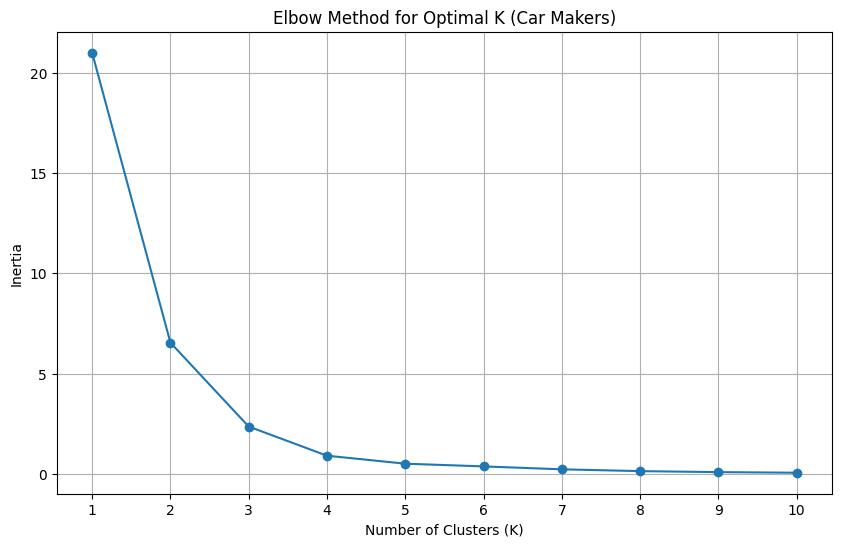


--- Clustering Results for Car Makers ---
Number of clusters chosen for Makers: 3

First 10 rows of Maker Clusters by Average CO2 Emissions:
          Maker  CO2EMISSIONS  Cluster
0  aston martin    359.000000        1
1       bentley    348.600000        1
2      maserati    347.000000        1
3        nissan    297.000000        2
4       porsche    280.482602        2
5         dodge    279.500000        2
6          audi    273.866667        2
7          ford    266.568627        2
8    volkswagen    255.923963        2
9           kia    245.098901        2


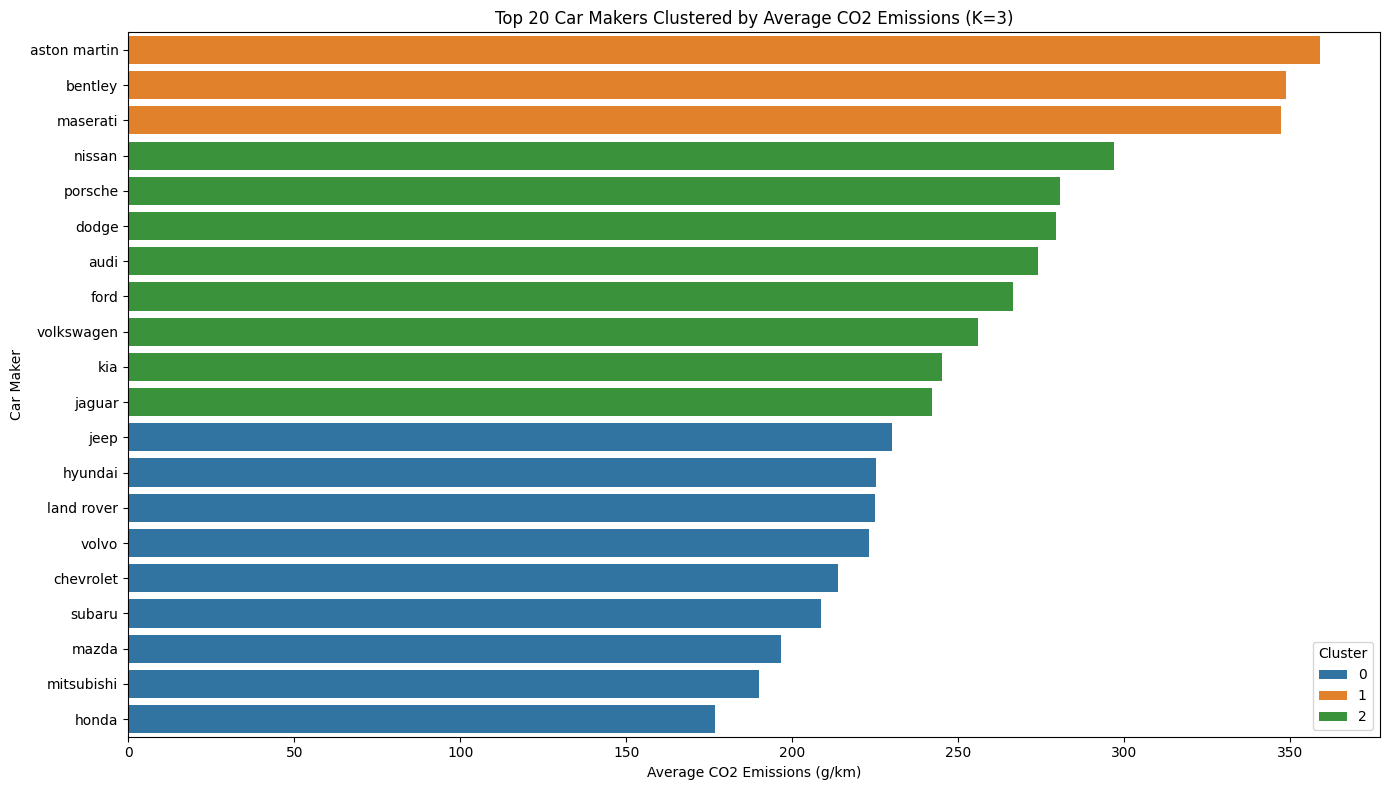

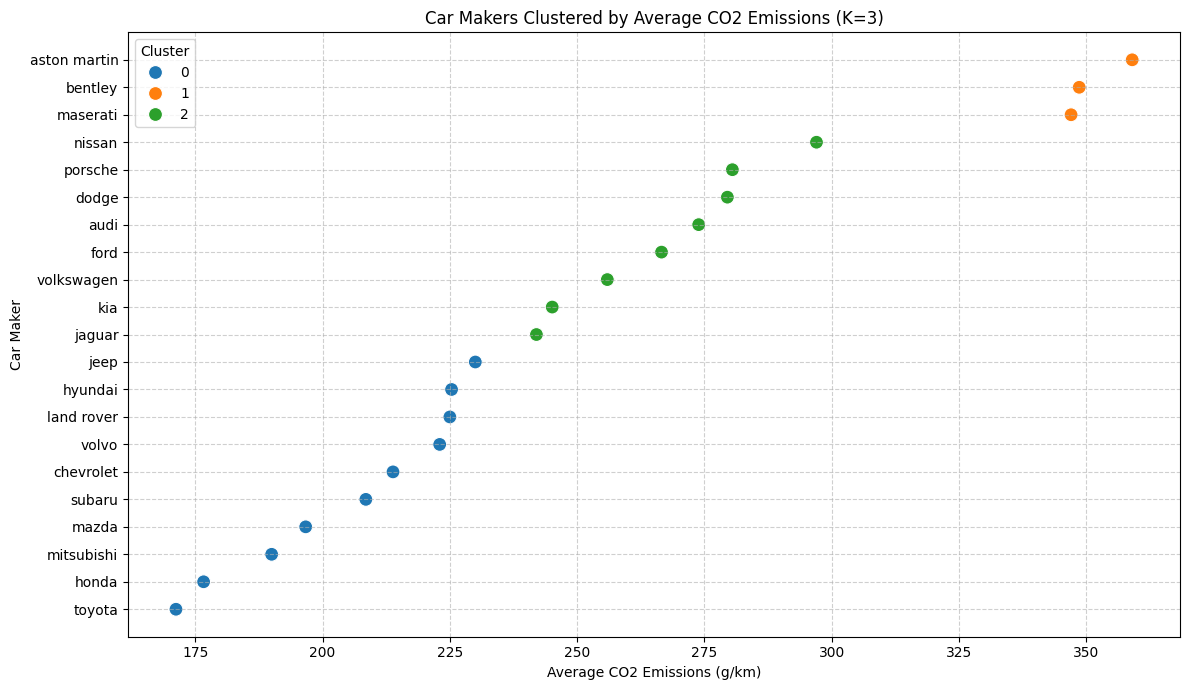

In [11]:
## K-Means Clustering
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
### Clustering Car Makers by Average CO2 Emissions

# 1. Prepare Data for Maker Clustering
maker_avg_co2 = matching_records.groupby('Maker')['CO2EMISSIONS'].mean().reset_index()
X_makers = maker_avg_co2[['CO2EMISSIONS']]

# Scale the data for clustering
scaler_makers = StandardScaler()
X_makers_scaled = scaler_makers.fit_transform(X_makers)

# 2. Determine K for Maker Clustering (Elbow Method)
inertia = []
range_n_clusters = range(1, 11)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X_makers_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Car Makers)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

# Based on visual inspection of the elbow method, let's choose K=3 or K=4. Let's proceed with K=3 as it aligns with previous categorization (even if one category was empty).
n_clusters_makers = 3

# 3. Perform K-Means Clustering for Makers
kmeans_makers = KMeans(n_clusters=n_clusters_makers, random_state=42, n_init=10)
maker_avg_co2['Cluster'] = kmeans_makers.fit_predict(X_makers_scaled)

# Sort makers by CO2 and then by cluster for better visualization
maker_avg_co2_sorted = maker_avg_co2.sort_values(by='CO2EMISSIONS', ascending=False).reset_index(drop=True)

print("\n--- Clustering Results for Car Makers ---")
print(f"Number of clusters chosen for Makers: {n_clusters_makers}")
print("\nFirst 10 rows of Maker Clusters by Average CO2 Emissions:")
print(maker_avg_co2_sorted.head(10))

# 4. Visualize Maker Clusters
plt.figure(figsize=(14, 8))
sns.barplot(x='CO2EMISSIONS', y='Maker', hue='Cluster', data=maker_avg_co2_sorted.head(20), palette='tab10', dodge=False)
plt.title(f'Top 20 Car Makers Clustered by Average CO2 Emissions (K={n_clusters_makers})')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Maker')
plt.tight_layout()
plt.show()

# Scatter plot for all makers
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CO2EMISSIONS', y='Maker', hue='Cluster', data=maker_avg_co2_sorted, palette='tab10', s=100)
plt.title(f'Car Makers Clustered by Average CO2 Emissions (K={n_clusters_makers})')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Maker')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



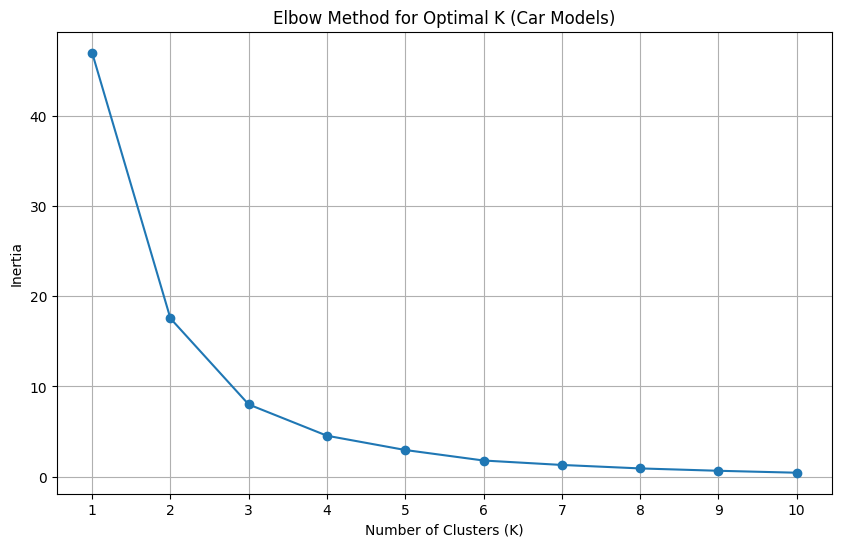


--- Clustering Results for Car Models ---
Number of clusters chosen for Models: 3

First 10 rows of Model Clusters by Average CO2 Emissions:
            Model  CO2EMISSIONS  Cluster
0        mulsanne         437.0        1
1              r8         376.5        1
2        vanquish         359.0        1
3     granturismo         347.0        1
4  continental gt         326.5        1
5         911 gt3         322.0        1
6              q7         304.0        2
7              s8         297.0        2
8            gt-r         297.0        2
9         cayenne         294.5        2


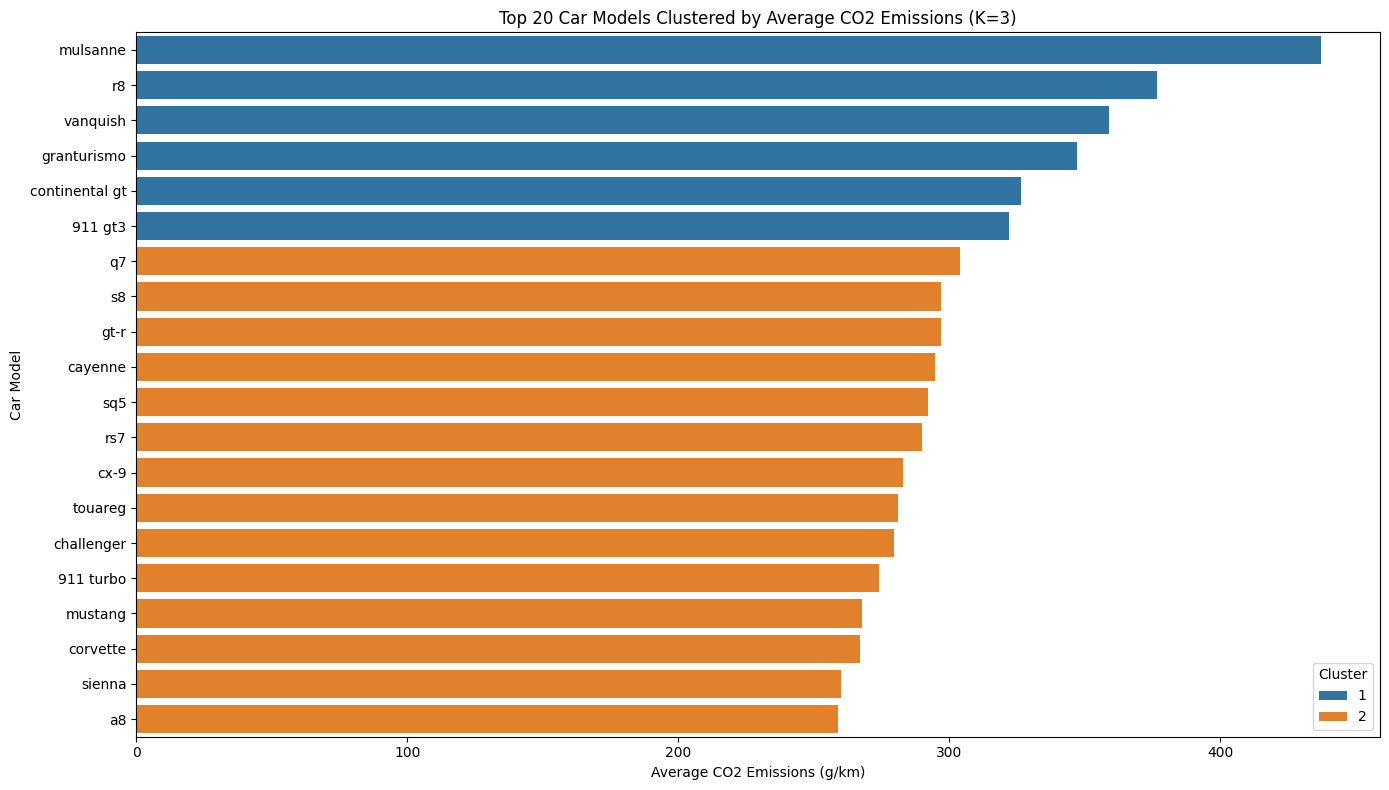

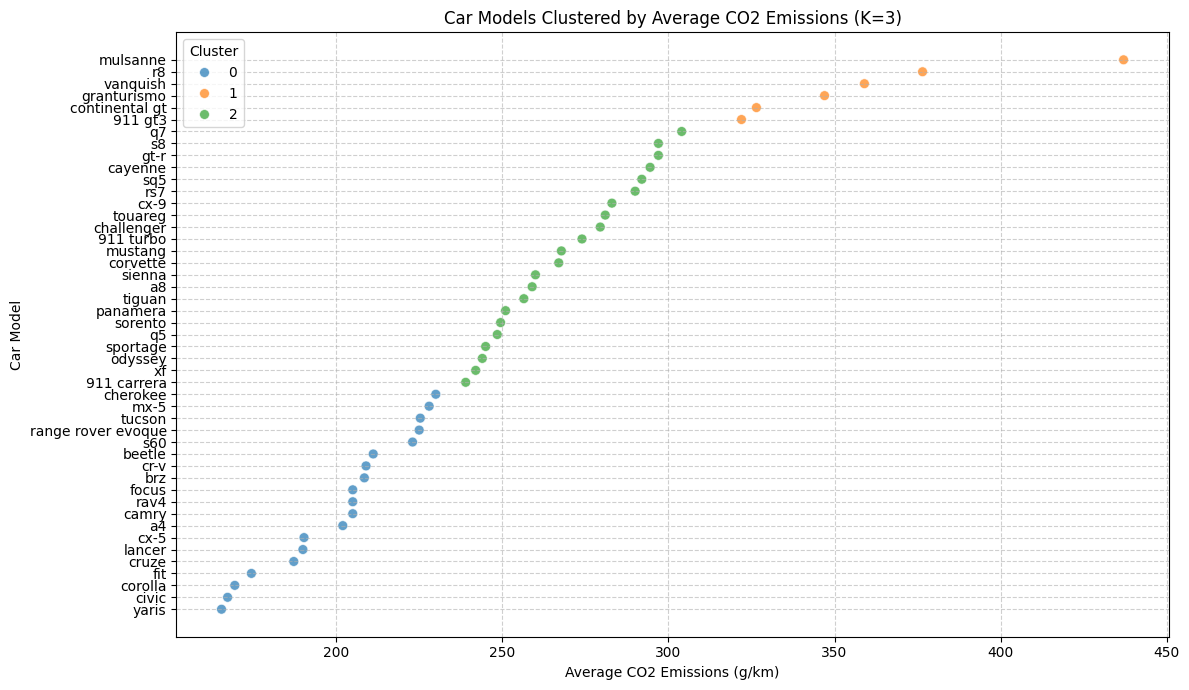

In [12]:
### Clustering Car Models by Average CO2 Emissions

# 5. Prepare Data for Model Clustering
model_avg_co2 = matching_records.groupby('Model')['CO2EMISSIONS'].mean().reset_index()
X_models = model_avg_co2[['CO2EMISSIONS']]

# Scale the data for clustering
scaler_models = StandardScaler()
X_models_scaled = scaler_models.fit_transform(X_models)

# 6. Determine K for Model Clustering (Elbow Method)
inertia = []
range_n_clusters = range(1, 11)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_models_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Car Models)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

# Based on visual inspection of the elbow method, let's also proceed with K=3 for models.
n_clusters_models = 3

# 7. Perform K-Means Clustering for Models
kmeans_models = KMeans(n_clusters=n_clusters_models, random_state=42, n_init=10)
model_avg_co2['Cluster'] = kmeans_models.fit_predict(X_models_scaled)

# Sort models by CO2 and then by cluster for better visualization
model_avg_co2_sorted = model_avg_co2.sort_values(by='CO2EMISSIONS', ascending=False).reset_index(drop=True)

print("\n--- Clustering Results for Car Models ---")
print(f"Number of clusters chosen for Models: {n_clusters_models}")
print("\nFirst 10 rows of Model Clusters by Average CO2 Emissions:")
print(model_avg_co2_sorted.head(10))

# 8. Visualize Model Clusters (show top 20 for clarity)
plt.figure(figsize=(14, 8))
sns.barplot(x='CO2EMISSIONS', y='Model', hue='Cluster', data=model_avg_co2_sorted.head(20), palette='tab10', dodge=False)
plt.title(f'Top 20 Car Models Clustered by Average CO2 Emissions (K={n_clusters_models})')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

# Scatter plot for all models (can be very dense, but provides full context)
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CO2EMISSIONS', y='Model', hue='Cluster', data=model_avg_co2_sorted, palette='tab10', s=50, alpha=0.7)
plt.title(f'Car Models Clustered by Average CO2 Emissions (K={n_clusters_models})')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Model')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()
